In [2]:
import pandas as pd

# Load the dataset from Google Drive
df = pd.read_csv(
    "/content/drive/MyDrive/Thiranex/Task-2/wine+quality/winequality-red.csv",
    sep=";"
)

# Display first 5 rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Check dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1599, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid     

In [4]:
# Basic statistical summary
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# Distribution of wine quality
print(df["quality"].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


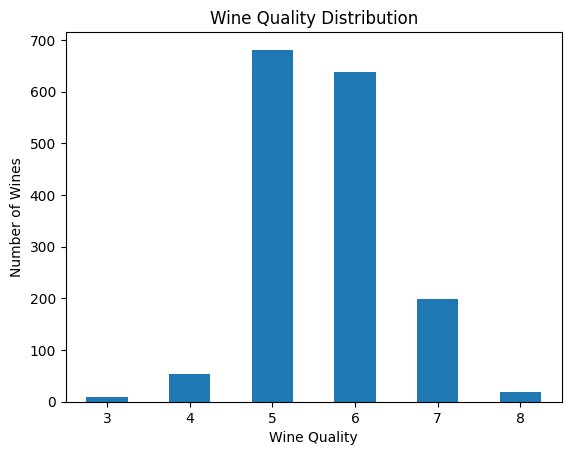

In [16]:
import matplotlib.pyplot as plt

# Wine Quality Distribution
df["quality"].value_counts().sort_index().plot(kind="bar")

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Correlation with wine quality
correlation = df.corr()["quality"].sort_values(ascending=False)
print(correlation)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Features and target
X = df.drop("quality", axis=1)
y = df["quality"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Training completed successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training completed successfully!
Training samples: 1279
Testing samples: 320


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))

# Evaluate
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Decision Tree
------------------------------
Accuracy : 0.6062
Precision: 0.6097
Recall   : 0.6062
F1 Score : 0.6066

Random Forest
------------------------------
Accuracy : 0.6781
Precision: 0.6531
Recall   : 0.6781
F1 Score : 0.6632


Decision Tree Confusion Matrix:
[[ 0  1  0  0  1  0]
 [ 1  3  4  3  0  0]
 [ 0  1 93 37  5  0]
 [ 0  3 34 71 15  5]
 [ 0  0  2 11 26  1]
 [ 0  0  1  0  1  1]]


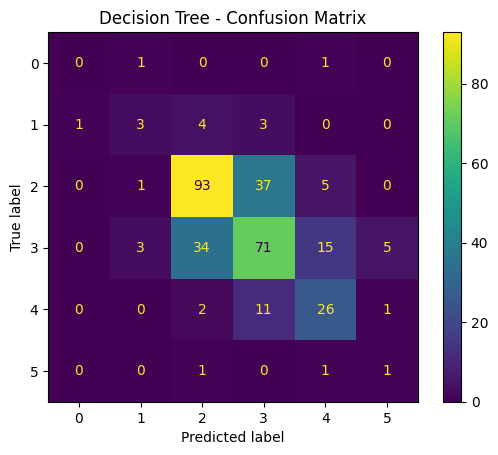


Random Forest Confusion Matrix:
[[  0   1   1   0   0   0]
 [  0   0   9   2   0   0]
 [  0   0 104  31   1   0]
 [  0   0  31  90   7   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]


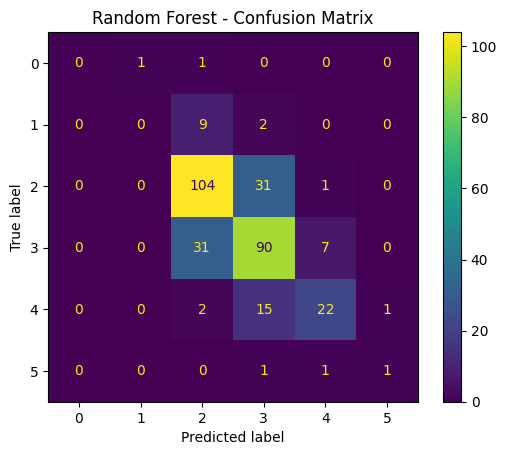

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt
).plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

ROC-AUC Scores
----------------
Decision Tree : 0.6974
Random Forest : 0.8376

Feature Importance:


,Feature,Decision Tree,Random Forest
10,alcohol,0.183838,0.152106
9,sulphates,0.134306,0.112057
1,volatile acidity,0.118186,0.103678
6,total sulfur dioxide,0.098721,0.101487
7,density,0.073024,0.088812
4,chlorides,0.073129,0.079941
8,pH,0.087091,0.079460
0,fixed acidity,0.058263,0.076209
3,residual sugar,0.062869,0.073386
2,citric acid,0.053693,0.068562


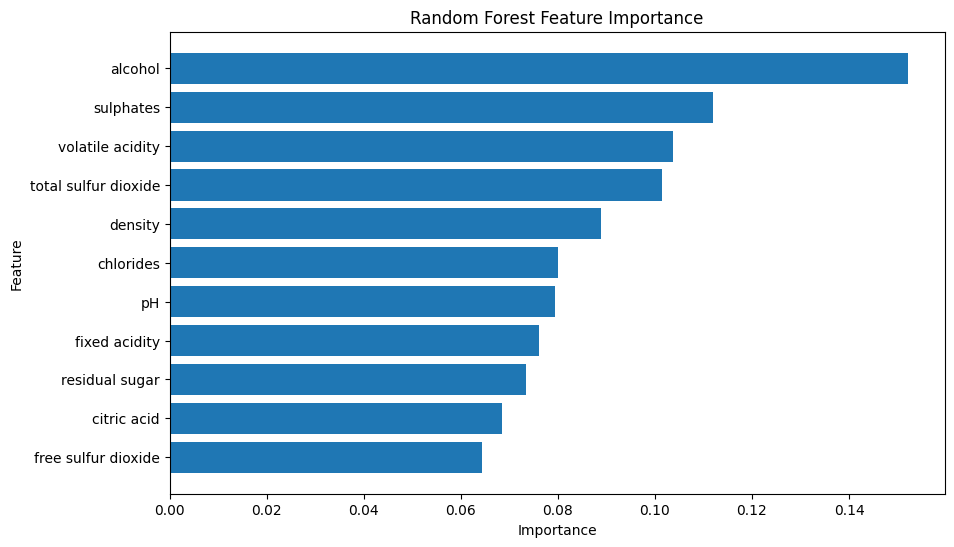

In [10]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import matplotlib.pyplot as plt

# ----- ROC-AUC -----
classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)

dt_proba = dt_model.predict_proba(X_test)
rf_proba = rf_model.predict_proba(X_test)

dt_auc = roc_auc_score(
    y_test_bin, dt_proba, multi_class="ovr", average="weighted"
)

rf_auc = roc_auc_score(
    y_test_bin, rf_proba, multi_class="ovr", average="weighted"
)

print("ROC-AUC Scores")
print("----------------")
print("Decision Tree :", round(dt_auc, 4))
print("Random Forest :", round(rf_auc, 4))


# ----- Feature Importance -----
importance = pd.DataFrame({
    "Feature": X.columns,
    "Decision Tree": dt_model.feature_importances_,
    "Random Forest": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Random Forest", ascending=False
)

print("\nFeature Importance:")
display(importance)


# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    importance["Feature"],
    importance["Random Forest"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [11]:
# Final model comparison

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred, average="weighted", zero_division=0),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, dt_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "ROC-AUC": [dt_auc, rf_auc]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.6062,0.6097,0.6062,0.6066,0.6974
1,Random Forest,0.6781,0.6531,0.6781,0.6632,0.8376


In [13]:
# Select the best model based on F1 Score

best_model = results.loc[results["F1 Score"].idxmax(), "Model"]

print("Best Model:", best_model)

Best Model: Random Forest


In [14]:
# Generate sample predictions

prediction_results = X_test.copy()

prediction_results["Actual Quality"] = y_test.values
prediction_results["Decision Tree Prediction"] = dt_pred
prediction_results["Random Forest Prediction"] = rf_pred

prediction_results[
    ["Actual Quality", "Decision Tree Prediction", "Random Forest Prediction"]
].head(10)

,Actual Quality,Decision Tree Prediction,Random Forest Prediction
963,6,7,6
475,5,6,6
1,5,5,5
329,5,6,6
149,6,5,5
1508,6,7,5
1243,5,6,6
38,4,5,5
108,6,6,5
495,8,8,8


In [15]:
# Save model comparison results
results.round(4).to_csv("model_comparison.csv", index=False)

# Save sample predictions
prediction_results.to_csv("wine_quality_predictions.csv", index=False)

print("Files saved successfully!")
print("1. model_comparison.csv")
print("2. wine_quality_predictions.csv")

Files saved successfully!
1. model_comparison.csv
2. wine_quality_predictions.csv


# Thiranex Task 2 — Wine Quality Prediction Using Machine Learning

## Project Overview

This project focuses on predicting wine quality using machine learning techniques. The UCI Wine Quality dataset for red wine was used for this analysis.

## Dataset

- **Dataset:** UCI Wine Quality — Red Wine
- **Records:** 1,599
- **Input Features:** 11
- **Target Variable:** `quality`
- **Problem Type:** Multi-class Classification

## Features Used

The prediction was based on the following physicochemical properties:

- Fixed Acidity
- Volatile Acidity
- Citric Acid
- Residual Sugar
- Chlorides
- Free Sulfur Dioxide
- Total Sulfur Dioxide
- Density
- pH
- Sulphates
- Alcohol

## Methodology

The following steps were performed:

1. Loaded the Wine Quality dataset.
2. Inspected the dataset structure and data types.
3. Checked for missing values.
4. Performed exploratory data analysis and statistical analysis.
5. Separated the input features and target variable.
6. Split the dataset into 80% training and 20% testing data.
7. Trained a Decision Tree Classifier.
8. Trained a Random Forest Classifier.
9. Evaluated both models using Accuracy, Precision, Recall, and F1 Score.
10. Generated confusion matrices for both models.
11. Calculated ROC-AUC scores.
12. Analyzed feature importance.
13. Compared the performance of both models.
14. Generated sample wine quality predictions.

## Machine Learning Models

### Decision Tree Classifier

A Decision Tree was used as a baseline classification model. It makes predictions by creating a series of decision rules based on the input features.

### Random Forest Classifier

A Random Forest was used as the second model. It combines multiple decision trees to improve prediction performance and reduce overfitting.

## Model Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## Feature Importance

Feature importance analysis was performed using the trained models to identify which physicochemical properties contributed most to predicting wine quality.

## Conclusion

The project successfully demonstrates the application of machine learning to wine quality prediction. Decision Tree and Random Forest classification models were trained and evaluated using multiple performance metrics.

The performance comparison helps identify the more suitable model for predicting wine quality from physicochemical properties. The project also demonstrates the importance of exploratory analysis, model evaluation, and feature importance in a machine learning workflow.